In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/microsoft-stock-price-history/Microsoft_stock_data.csv


In [2]:
df = pd.read_csv("/kaggle/input/microsoft-stock-price-history/Microsoft_stock_data.csv")
df.head()

,Date,Close,High,Low,Open,Volume
0,1986-03-13,0.059598,0.062259,0.054277,0.054277,1031788800
1,1986-03-14,0.061726,0.062791,0.059598,0.059598,308160000
2,1986-03-17,0.062791,0.063323,0.061726,0.061726,133171200
3,1986-03-18,0.061194,0.063323,0.060662,0.062791,67766400
4,1986-03-19,0.060130,0.061726,0.059598,0.061194,47894400


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9892 entries, 0 to 9891
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    9892 non-null   object 
 1   Close   9892 non-null   float64
 2   High    9892 non-null   float64
 3   Low     9892 non-null   float64
 4   Open    9892 non-null   float64
 5   Volume  9892 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 463.8+ KB


In [4]:
df.describe()

,Close,High,Low,Open,Volume
count,9892.000000,9892.000000,9892.000000,9892.000000,9.892000e+03
mean,60.536132,61.119820,59.898151,60.515166,5.599959e+07
std,103.704786,104.623132,102.671666,103.661663,3.808651e+07
min,0.055341,0.056405,0.054277,0.054277,2.304000e+06
25%,3.687611,3.735502,3.634931,3.686414,3.099000e+07
50%,19.340508,19.528971,19.095554,19.327117,4.917040e+07
75%,41.031258,41.375402,40.616786,41.004586,6.997710e+07
max,479.140015,480.690002,475.000000,476.410004,1.031789e+09


In [5]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df['Date'] = pd.to_datetime(df['Date'])

df = df.sort_values('Date')
df.set_index('Date', inplace =True)


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


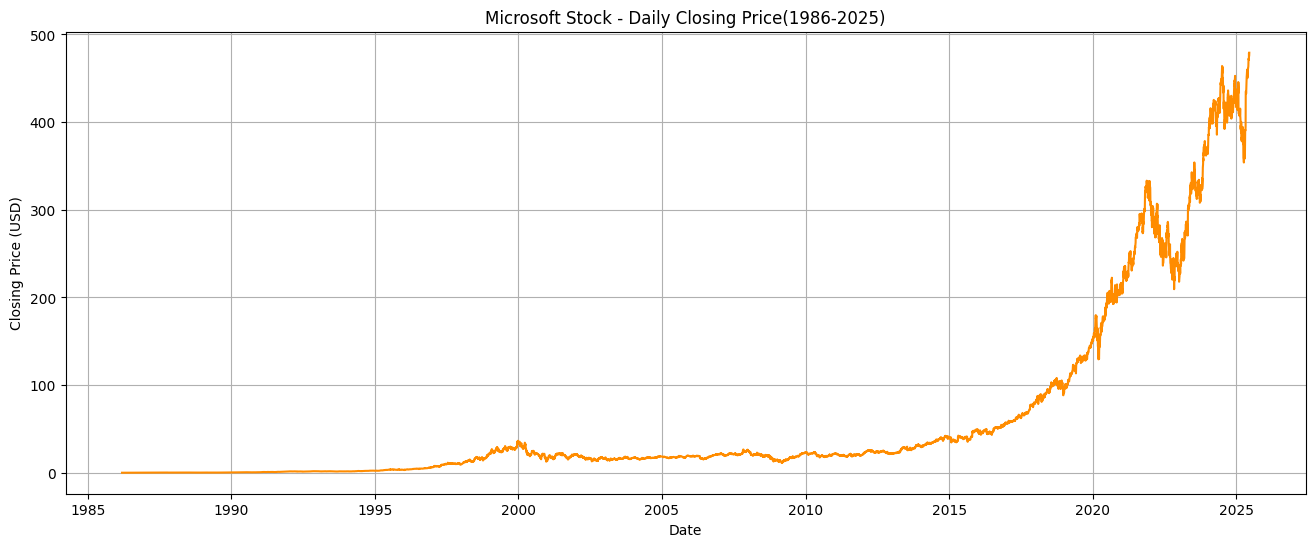

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,6))
sns.lineplot(data=df['Close'], color='darkorange')
plt.title('Microsoft Stock - Daily Closing Price(1986-2025)')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.grid(True)
plt.show()


ADF Statistic: 4.225383108674562
p-value: 1.0


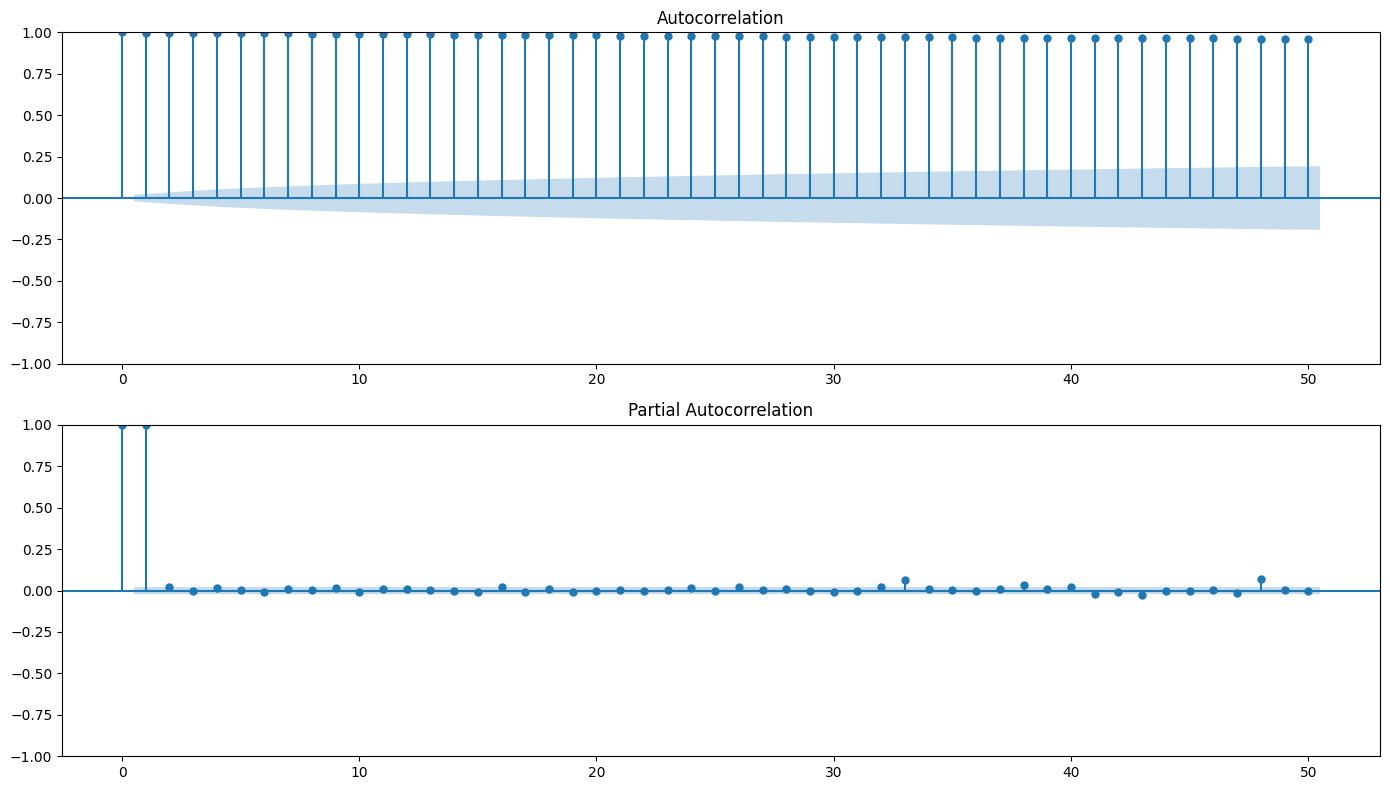

In [9]:

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df['Close'])
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

# 4. ACF/PACF of Raw Series
fig, ax = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(df['Close'], lags=50, ax=ax[0])
plot_pacf(df['Close'], lags=50, ax=ax[1])
plt.tight_layout()
plt.show()

ADF Statistic (1st diff): -16.14415563824056
p-value: 4.6422485135843415e-29


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


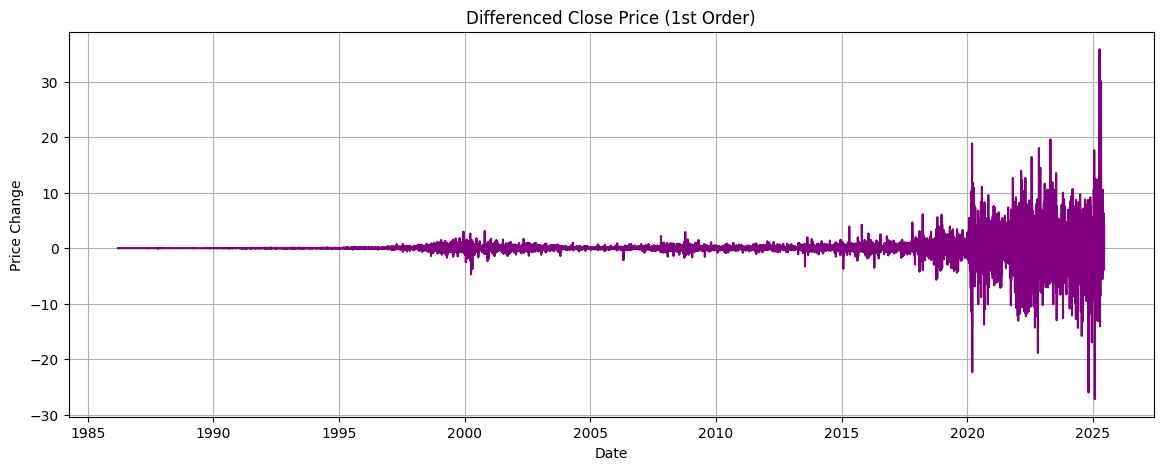

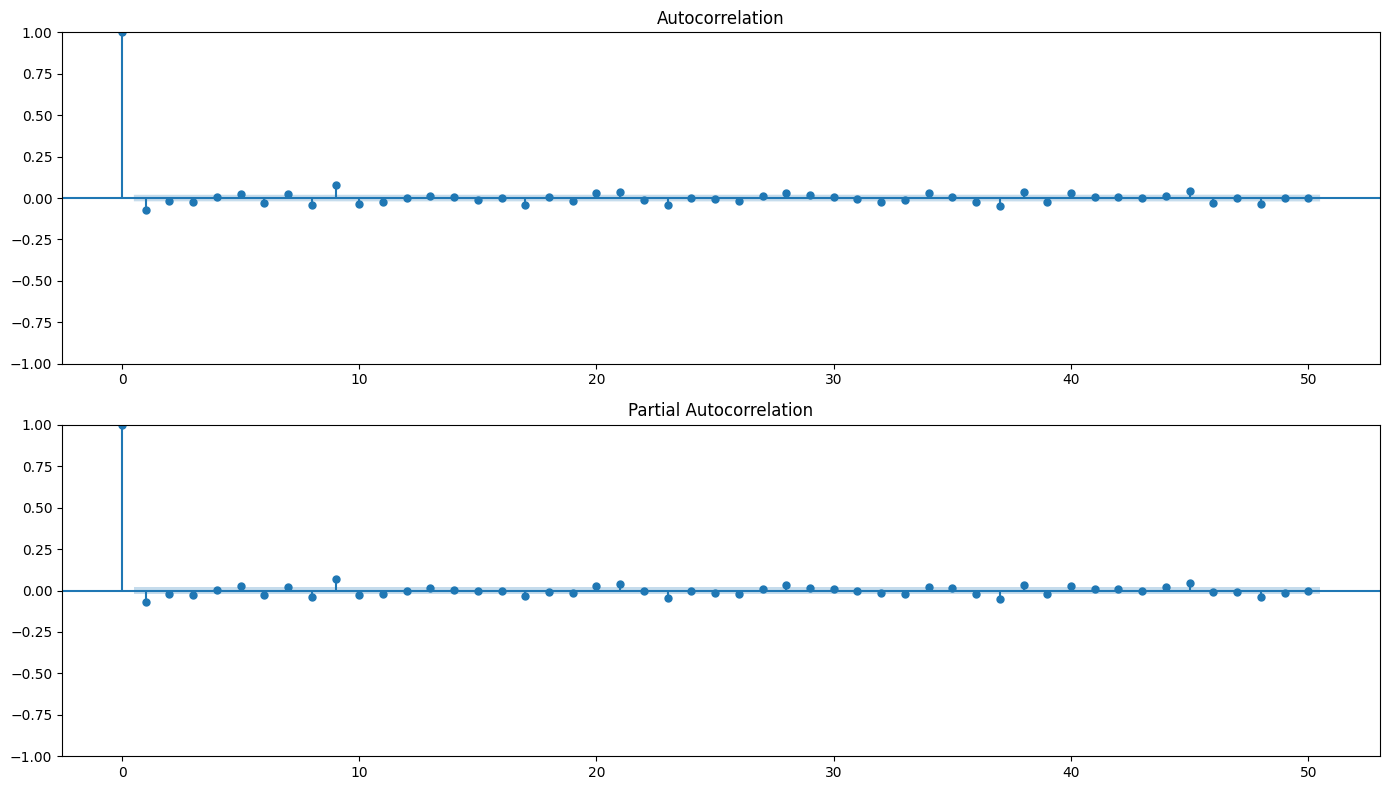

In [10]:
# First-order differencing
df_diff = df['Close'].diff().dropna()

# ADF test after differencing
from statsmodels.tsa.stattools import adfuller
adf_diff = adfuller(df_diff)
print(f"ADF Statistic (1st diff): {adf_diff[0]}")
print(f"p-value: {adf_diff[1]}")

# Plot differenced series
plt.figure(figsize=(14, 5))
sns.lineplot(data=df_diff, color='purple')
plt.title("Differenced Close Price (1st Order)")
plt.xlabel("Date")
plt.ylabel("Price Change")
plt.grid(True)
plt.show()

# ACF and PACF of differenced data
fig, ax = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(df_diff, lags=50, ax=ax[0])
plot_pacf(df_diff, lags=50, ax=ax[1])
plt.tight_layout()
plt.show()


In [11]:
# ARIMA
train = df['Close'][:-365]
test = df['Close'][-365:]


In [12]:
from statsmodels.tsa.arima.model import ARIMA
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA


model = ARIMA(train, order=(1,1,1))
model_fit = model.fit()


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [13]:
forecast = model_fit.forecast(steps=365)

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [14]:
forecast_df = pd.DataFrame({
    "Actual" : test,
    "Forecast" : forecast
})

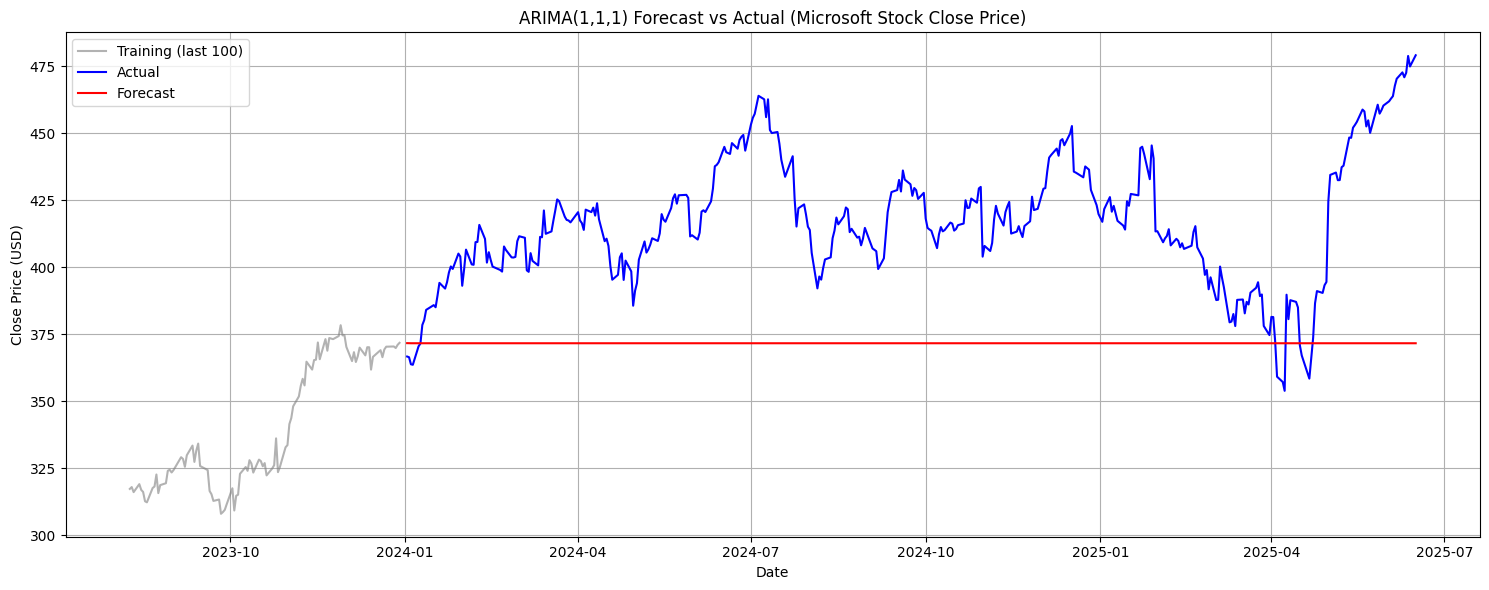

In [15]:
plt.figure(figsize=(15, 6))

# Plot last 100 days of training data
plt.plot(train.index[-100:], train[-100:], label='Training (last 100)', color='gray', alpha=0.6)

# Plot actual values (test set)
plt.plot(test.index, test, label='Actual', color='blue')

# Plot ARIMA forecast
plt.plot(test.index, forecast, label='Forecast', color='red')

plt.title("ARIMA(1,1,1) Forecast vs Actual (Microsoft Stock Close Price)")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [16]:
# Convert test and forecast to float arrays
actual_values = test.values.astype(float)
predicted_values = forecast.values.astype(float)

# Recalculate MAPE
mape_fixed = np.mean(np.abs((actual_values - predicted_values) / actual_values)) * 100
mape_fixed


10.627448243571646

In [17]:
!pip install prophet --quiet


In [18]:
from prophet import Prophet


In [19]:
prophet_df = df['Close'].reset_index().rename(columns={'Date': 'ds', 'Close': 'y'})


In [20]:
m = Prophet(daily_seasonality=True)

In [21]:
# Prophet Train/Test Split: last 365 days as test set
prophet_train = prophet_df.iloc[:-365]
prophet_test = prophet_df.iloc[-365:]


In [22]:
m.fit(prophet_train)

13:56:10 - cmdstanpy - INFO - Chain [1] start processing
13:56:21 - cmdstanpy - INFO - Chain [1] done processing


In [23]:
future = m.make_future_dataframe(periods=365)

forecast_prophet = m.predict(future)

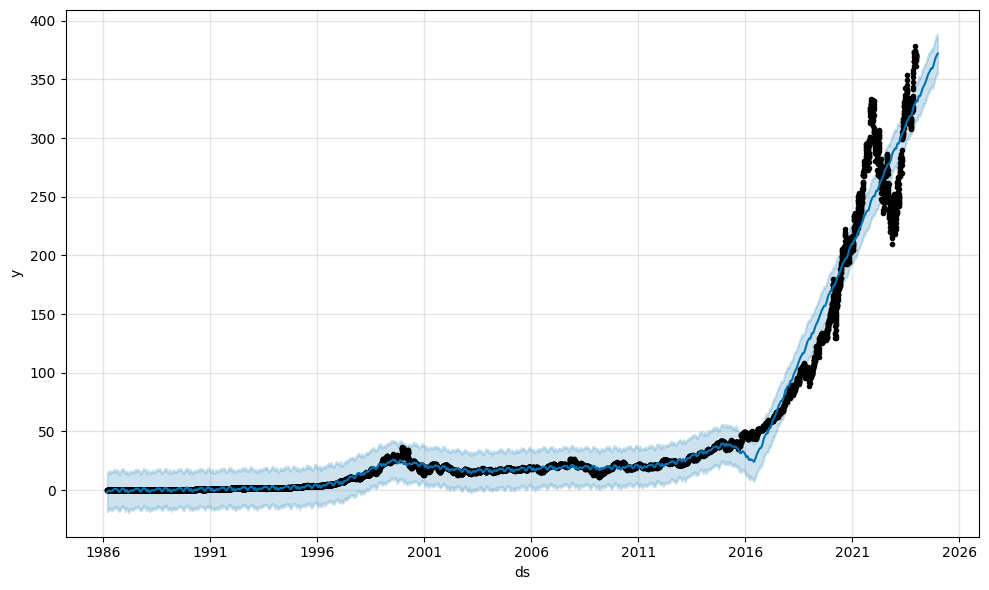

In [24]:
fig = m.plot(forecast_prophet)

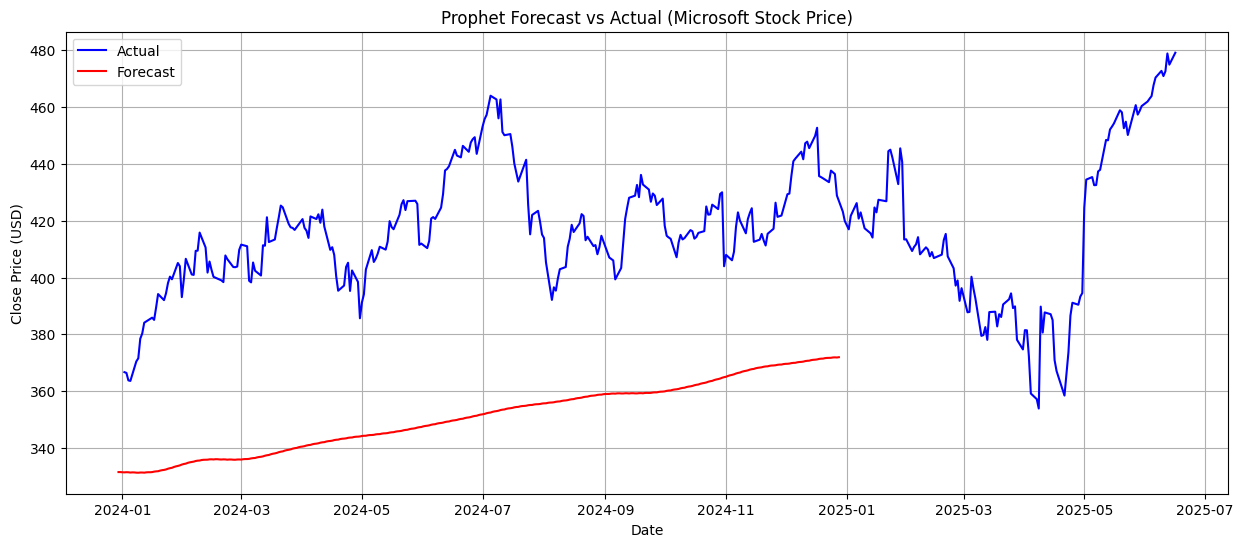

In [25]:
# Extract only test predictions
forecast_only = forecast_prophet[['ds', 'yhat']].iloc[-365:]

# Plot comparison
plt.figure(figsize=(15, 6))
plt.plot(prophet_test['ds'], prophet_test['y'], label='Actual', color='blue')
plt.plot(forecast_only['ds'], forecast_only['yhat'], label='Forecast', color='red')
plt.title("Prophet Forecast vs Actual (Microsoft Stock Price)")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


In [26]:
# Convert to float arrays
actual = prophet_test['y'].values.astype(float)
predicted = forecast_only['yhat'].values.astype(float)

# Compute MAPE
mape_prophet = np.mean(np.abs((actual - predicted) / actual)) * 100
print(f"Prophet MAPE: {mape_prophet:.2f}%")


Prophet MAPE: 15.55%


In [27]:
# XGBoost
import numpy as np

# Create lag and rolling mean features
df_features = df.copy()
df_features["lag_1"] = df_features["Close"].shift(1)
df_features["lag_2"] = df_features["Close"].shift(2)
df_features["lag_3"] = df_features["Close"].shift(3)
df_features["rolling_mean_3"] = df_features["Close"].rolling(window=3).mean()
df_features["rolling_std_3"] = df_features["Close"].rolling(window=3).std()
df['lag_1'] = df['Close'].shift(1)
df['lag_2'] = df['Close'].shift(2)
df['rolling_7'] = df['Close'].rolling(7).mean()
df['rolling_14'] = df['Close'].rolling(14).mean()
df['rolling_std_7'] = df['Close'].rolling(7).std()
df['momentum'] = df['Close'] - df['Close'].shift(5)
df['daily_return'] = df['Close'].pct_change()


# Drop missing values created by lags/rollings
df_features = df_features.dropna()


In [28]:
df['dayofweek'] = df.index.dayofweek
df['day'] = df.index.day
df['month'] = df.index.month
df['quarter'] = df.index.quarter


In [29]:
df_features.head()

,Close,High,Low,Open,Volume,lag_1,lag_2,lag_3,rolling_mean_3,rolling_std_3
Date,,,,,,,,,,
1986-03-18,0.061194,0.063323,0.060662,0.062791,67766400,0.062791,0.061726,0.059598,0.061904,0.000813
1986-03-19,0.060130,0.061726,0.059598,0.061194,47894400,0.061194,0.062791,0.061726,0.061371,0.001339
1986-03-20,0.058533,0.060130,0.058001,0.060130,58435200,0.060130,0.061194,0.062791,0.059952,0.001339
1986-03-21,0.056937,0.059598,0.055873,0.058533,59990400,0.058533,0.060130,0.061194,0.058533,0.001596
1986-03-24,0.055341,0.056937,0.054809,0.056937,65289600,0.056937,0.058533,0.060130,0.056937,0.001596


In [30]:
from sklearn.preprocessing import StandardScaler

# Drop target and get features
X = df_features.drop(columns=['Close'])

# Fit scaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(X)

# Use the same index and columns from df_features (not df)
df_scaled = pd.DataFrame(scaled_features, index=df_features.index, columns=X.columns)

# Add back the unscaled target column
df_scaled['Close'] = df_features['Close'].values


In [31]:

# Use last 365 days as test set
train_data = df_scaled[:-365]
test_data = df_scaled[-365:]

X_train = train_data.drop("Close", axis=1)
y_train = train_data["Close"]

X_test = test_data.drop("Close", axis=1)
y_test = test_data["Close"]


In [32]:
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

model = XGBRegressor()
grid = GridSearchCV(model, param_grid, scoring='neg_mean_absolute_error', cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_



In [33]:
# Predict on test set
y_pred = best_model.predict(X_test)



In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error


mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"XGBoost MAE: {mae:.2f}")
print(f"XGBoost RMSE: {rmse:.2f}")
print(f"XGBoost MAPE: {mape:.2f}%")


XGBoost MAE: 50.35
XGBoost RMSE: 55.24
XGBoost MAPE: 11.83%


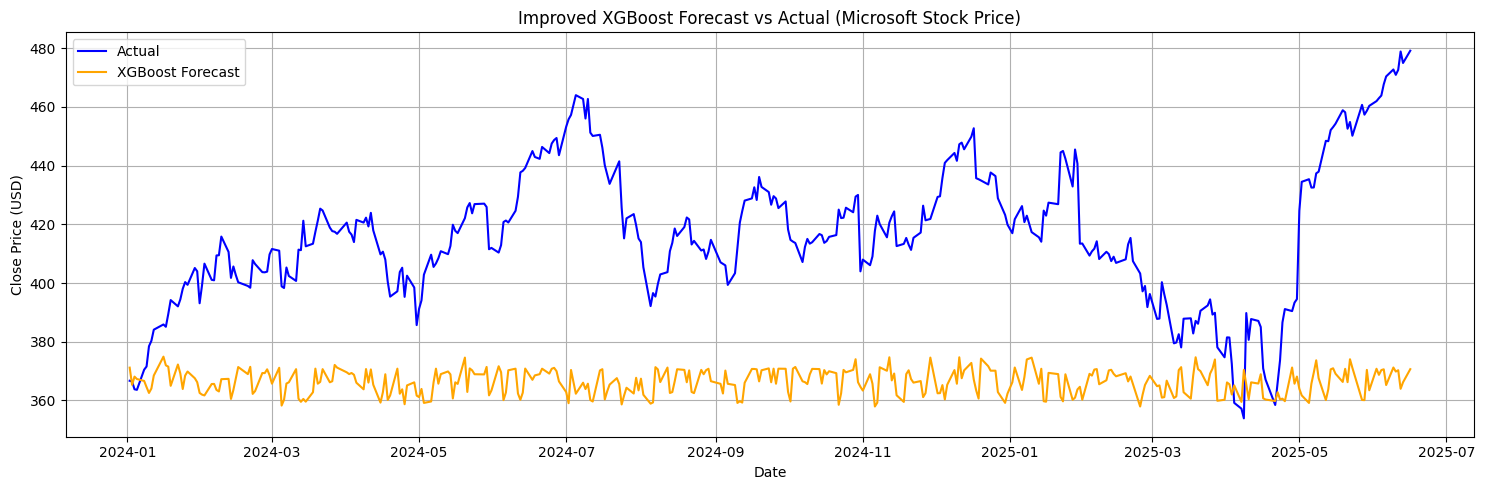

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))
plt.plot(y_test.index, y_test.values, label="Actual", color="blue")
plt.plot(y_test.index, y_pred, label="XGBoost Forecast", color="orange")
plt.title("Improved XGBoost Forecast vs Actual (Microsoft Stock Price)")
plt.xlabel("Date")
plt.ylabel("Close Price (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [36]:
print("Best Parameters from GridSearchCV:", grid.best_params_)


Best Parameters from GridSearchCV: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
